In [63]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

print("Week 4 Logistic Regression")

Week 4 Logistic Regression


In [64]:
df = pd.read_csv('/content/placement_predict_50k.csv')

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (50000, 31)


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly
0,1,Female,Delhi,Tier3,IT,DataScience,Yes,Yes,6.39,6.84,...,1,0,62.3,6.57,40.6,65.7,No,Medium,0,0
1,2,Male,Chennai,Tier2,ECE,AI,Yes,No,5.95,6.74,...,2,0,44.0,5.86,40.3,51.8,No,Medium,0,0
2,3,Female,Hyderabad,Tier3,ECE,Networking,No,No,7.13,8.11,...,2,1,73.8,7.50,73.6,67.9,No,High,1,0
3,4,Female,Jaipur,Tier3,ECE,Embedded,No,No,9.37,9.97,...,6,2,100.0,9.41,98.7,NaN,No,Excellent,1,0
4,5,Male,Ahmedabad,Tier3,Mechanical,DataScience,No,No,8.25,8.99,...,4,2,90.8,9.24,83.1,100.0,No,Excellent,1,0


In [65]:
df = df.drop(columns=['IsAnomaly'], errors='ignore')

for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values:", df.isnull().sum().sum())
print("Shape:", df.shape)

Missing values: 0
Shape: (50000, 30)


In [66]:
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop(columns=['PlacementStatus'])
y = df_encoded['PlacementStatus']

print("Features:", X.shape)
print("Target:", y.shape)

Features: (50000, 45)
Target: (50000,)


In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (40000, 45)
Testing data: (10000, 45)


In [68]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed")
print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

Feature scaling completed
Training shape: (40000, 45)
Testing shape: (10000, 45)


In [69]:
model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Binary Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred))

Binary Logistic Regression Accuracy: 0.791


In [70]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80      5250
           1       0.78      0.78      0.78      4750

    accuracy                           0.79     10000
   macro avg       0.79      0.79      0.79     10000
weighted avg       0.79      0.79      0.79     10000



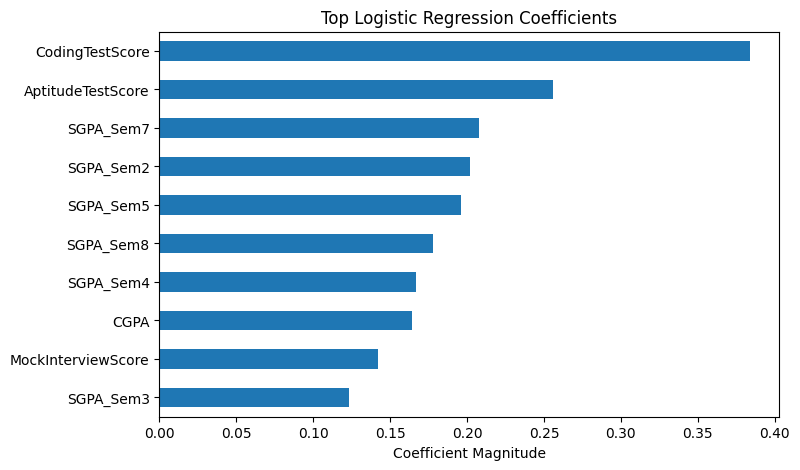

In [71]:
coefficients = pd.Series(
    model.coef_[0],
    index=X.columns
)

top_coefficients = coefficients.abs().sort_values(
    ascending=False
).head(10)

top_coefficients.sort_values().plot(
    kind='barh',
    figsize=(8, 5)
)

plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient Magnitude")
plt.show()

In [73]:
def evaluate_classifier(model, X_train, y_train, X_test, y_test):

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    print("Training Accuracy:", accuracy_score(y_train, train_pred))
    print("Testing Accuracy:", accuracy_score(y_test, test_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, test_pred))

In [74]:
evaluate_classifier(
    model,
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test
)

Training Accuracy: 0.79635
Testing Accuracy: 0.791

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80      5250
           1       0.78      0.78      0.78      4750

    accuracy                           0.79     10000
   macro avg       0.79      0.79      0.79     10000
weighted avg       0.79      0.79      0.79     10000

